In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Функции для чтения csv-файлов с сигналами и построения графиков:

In [2]:
def load_csv(filename):
    data = pd.read_csv(filename)
    index = data["index"].to_numpy()
    values = data["real"].to_numpy() + 1j * data["imag"].to_numpy()
    return index, values

def plot_fft(input_path, spectrum_path, output_path, title):
    input_path = Path(input_path)
    spectrum_path = Path(spectrum_path)
    output_path = Path(output_path)

    input_index, input_signal = load_csv(input_path)
    spectrum_index, input_spectrum = load_csv(spectrum_path)
    output_index, output_signal = load_csv(output_path)

    error = np.abs(output_signal - input_signal)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    fig.suptitle(
        f"{title}\n"
        f"MAE = {np.mean(error):.3e}, max error = {np.max(error):.3e}",
        fontsize=15
    )

    ax = axes[0, 0]
    ax.plot(input_index, input_signal.real, label="input real")
    ax.plot(output_index, output_signal.real, "--", label="output real")
    ax.set_title("Signal: real part")
    ax.set_xlabel("Index")
    ax.set_ylabel("Re")
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.legend()

    ax = axes[0, 1]
    ax.plot(input_index, input_signal.imag, label="input imag")
    ax.plot(output_index, output_signal.imag, "--", label="output imag")
    ax.set_title("Signal: imaginary part")
    ax.set_xlabel("Index")
    ax.set_ylabel("Im")
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.legend()

    ax = axes[1, 0]
    ax.plot(spectrum_index, input_spectrum.real, color="navy", lw=0.7, label="input spectrum abs")
    ax.set_title("Spectrum: real part")
    ax.set_xlabel("Frequency index")
    ax.set_ylabel("Re")
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.legend()

    ax = axes[1, 1]
    ax.plot(spectrum_index, input_spectrum.imag, color="navy", lw=0.7, label="input spectrum phase")
    ax.set_title("Spectrum: imaginary part")
    ax.set_xlabel("Frequency index")
    ax.set_ylabel("Im")
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

def plot_all_fft_results(n_values, data_dir="data"):
    data_dir = Path(data_dir)

    input_dir = data_dir / "input"
    output_dir = data_dir / "output"
    spectrum_dir = data_dir / "spectrum"

    for n in n_values:
        prefix = f"N_{n}"

        input_path = input_dir / f"{prefix}_input_signal.csv"
        spectrum_path = spectrum_dir / f"{prefix}_spectrum.csv"
        output_path = output_dir / f"{prefix}_output_signal.csv"

        plot_fft(
            input_path=input_path,
            spectrum_path=spectrum_path,
            output_path=output_path,
            title=prefix
        )

Построим входной и выходный сигналы на сравнительных графиках, а так же спектр входного для некоторых случайных наборов комплексных значений:

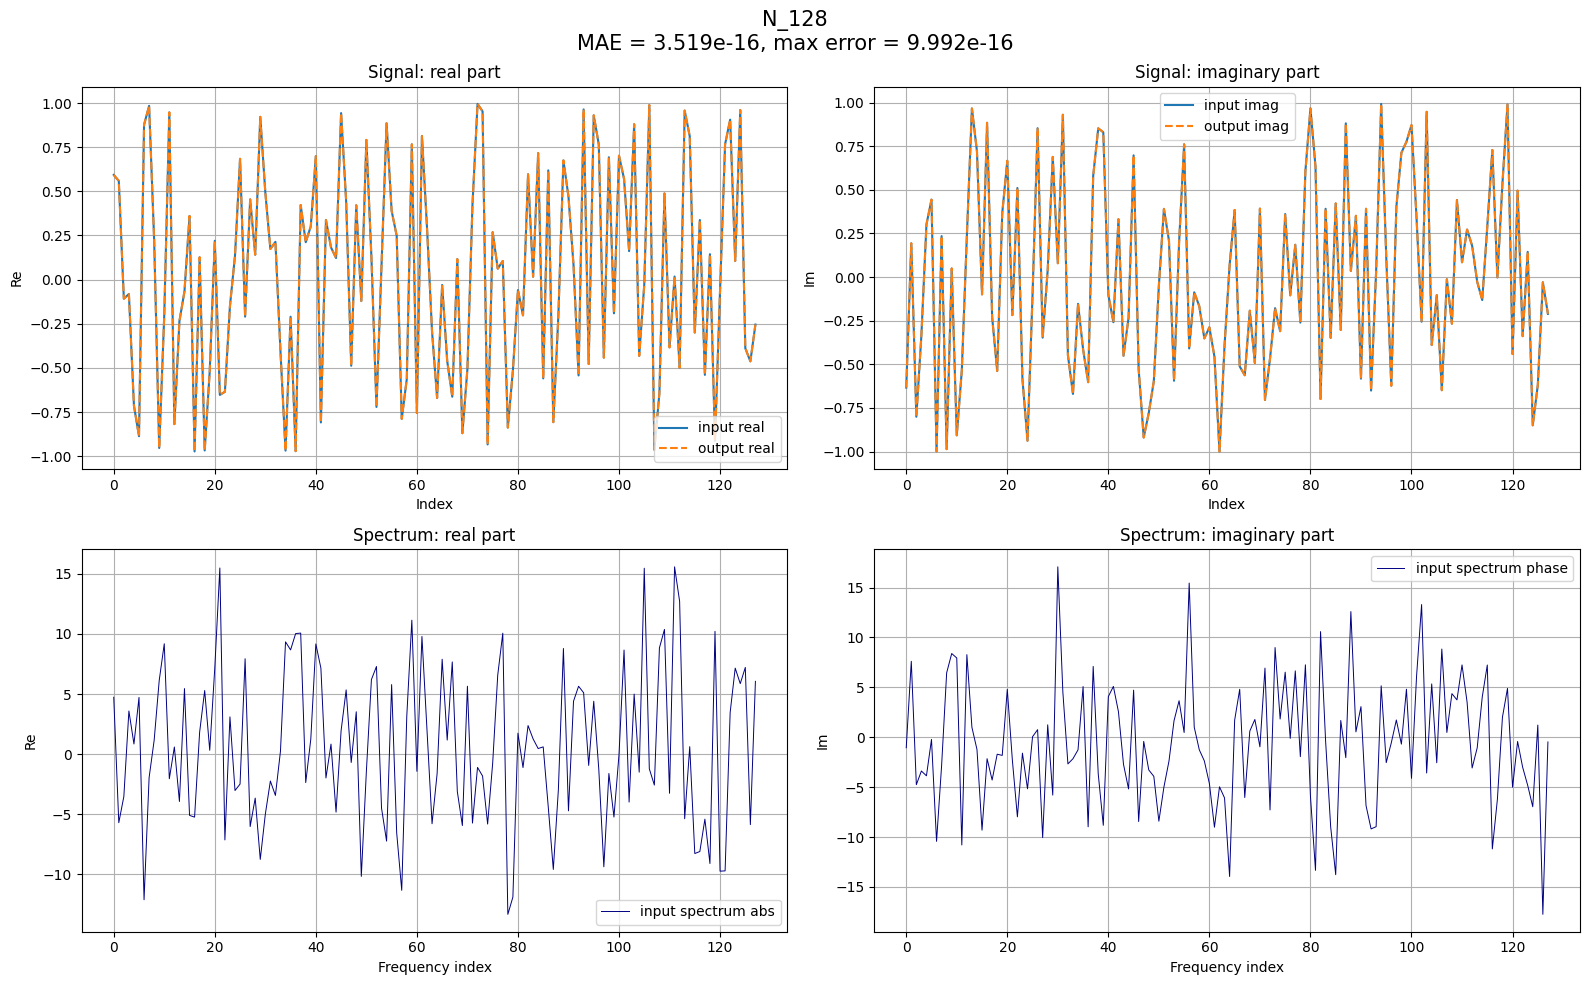

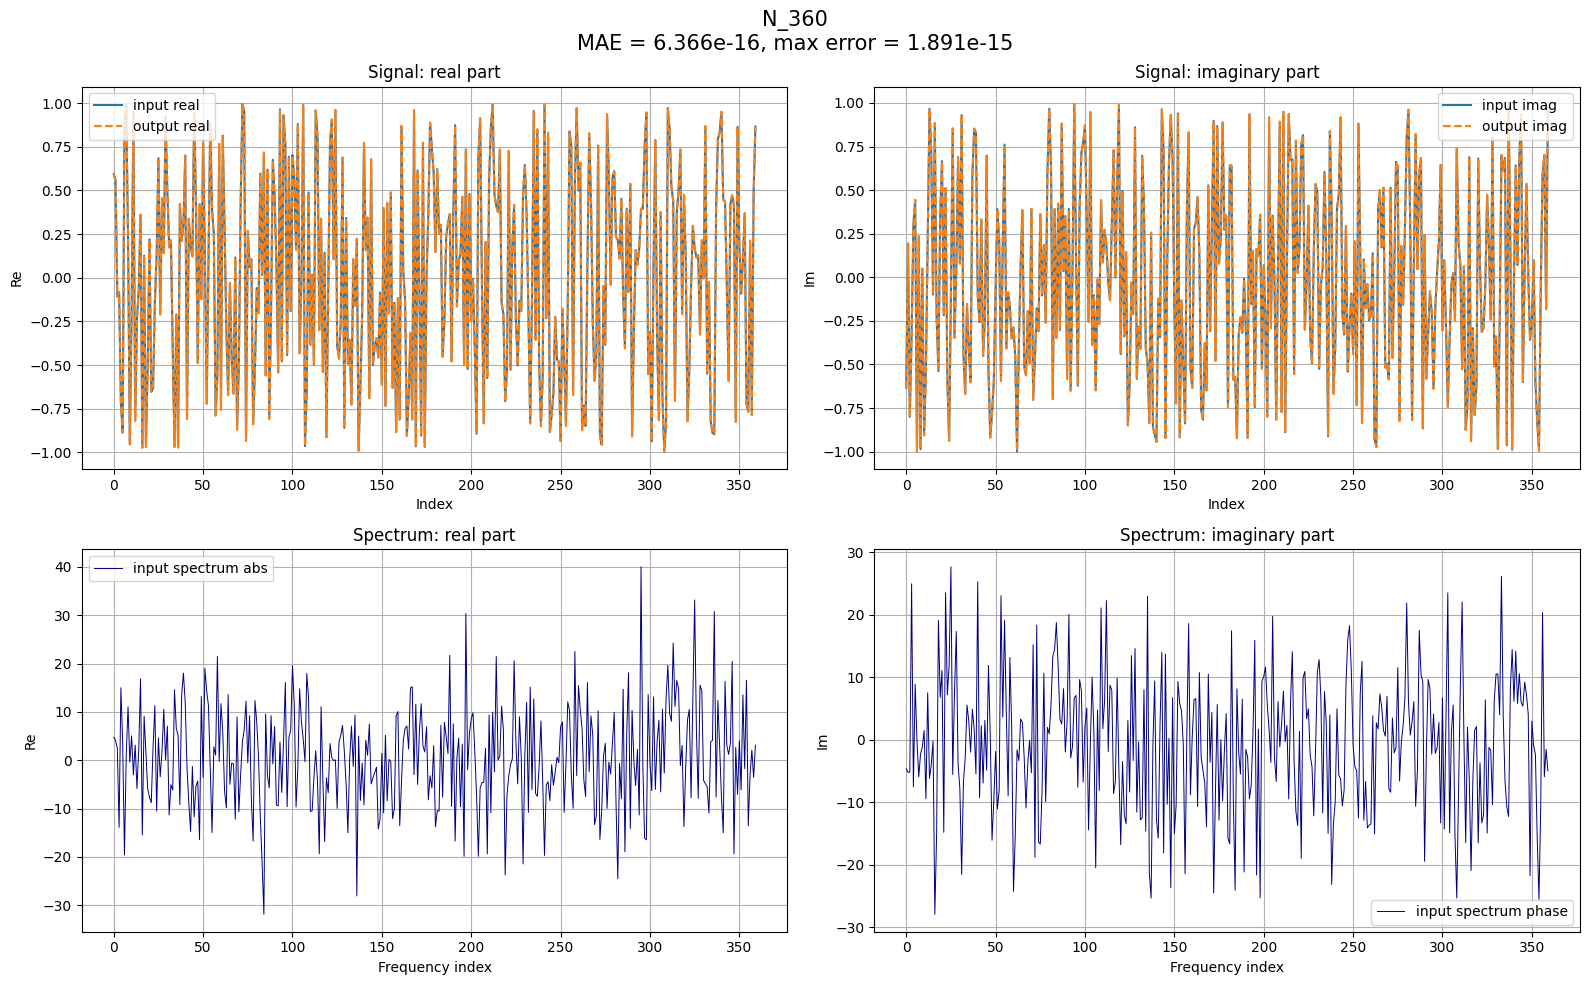

In [ ]:
plot_all_fft_results((128, 360)) #Тут указываются N, результаты для которых функция ищет в папке 